# Fig 7 — E7 ABR composability (filtered + aligned, zero filter delay)

Same layout as Fig 5 (E6) but for E7: a filtered client with
switchMode=aligned and filterDelay=0. 9 ABR configs x 3 bandwidth
profiles, 5 runs each. Isolates aligned switching from the deliberate
behind-live offset E6 carries.

Heat map: avg delivered bitrate (kbps), n_switches overlaid.
Right strip: max |playhead gap| per cell — aligned mode holds it
within one GOP across the whole sweep.

Robust to missing E7 data: cells with no runs render as "—".

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "figures"))

import matplotlib.pyplot as plt
import numpy as np

from _data import (
    E6_COL_ORDER,
    E6_ROW_ORDER,
    e7_avg_bitrate_matrix,
)
from _style import apply_acm_style

apply_acm_style()

In [2]:
bitrate_matrix = e7_avg_bitrate_matrix()

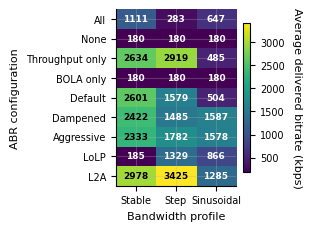

In [3]:
PROFILE_DISPLAY = {
    "stable1.5M":  "Stable",
    "step3M_500k": "Step",
    "sin600k_3M":  "Sinusoidal",
}
CONFIG_DISPLAY = {
    "none":            "None",
    "all":             "All",
    "throughput-only": "Throughput only",
    "bola-only":       "BOLA only",
    "default":         "Default",
    "dampened":        "Dampened",
    "aggressive":      "Aggressive",
    "lolp":            "LoLP",
    "l2a":             "L2A",
}

fig, ax_heat = plt.subplots(figsize=(3.0, 2.2), constrained_layout=True)

# Heat map.
masked = np.ma.masked_invalid(bitrate_matrix.values)
im = ax_heat.imshow(masked, cmap="viridis", aspect="auto",
                    interpolation="nearest", origin="upper")
ax_heat.set_xticks(range(len(E6_COL_ORDER)))
ax_heat.set_xticklabels(
    [PROFILE_DISPLAY.get(p, p).split("\n")[0] for p in E6_COL_ORDER],
    rotation=0, ha="center", fontsize=7,
)
ax_heat.set_yticks(range(len(E6_ROW_ORDER)))
ax_heat.set_yticklabels(
    [CONFIG_DISPLAY.get(c, c) for c in E6_ROW_ORDER],
    fontsize=7,
)
ax_heat.set_xlabel("Bandwidth profile")
ax_heat.set_ylabel("ABR configuration")

# Cell text overlays.
for i, row in enumerate(E6_ROW_ORDER):
    for j, col in enumerate(E6_COL_ORDER):
        bitrate = bitrate_matrix.iloc[i, j]
        if np.isnan(bitrate):
            ax_heat.text(j, i, "n/a", ha="center", va="center",
                         color="#999999", fontsize=7)
            continue
        rgba = im.cmap(im.norm(bitrate))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "white" if luminance < 0.5 else "black"
        ax_heat.text(j, i, f"{bitrate:.0f}", ha="center", va="center",
                     color=text_color, fontsize=6.5, weight="bold")

cbar = fig.colorbar(im, ax=ax_heat, shrink=0.85, pad=0.02)
cbar.set_label("Average delivered bitrate (kbps)", rotation=270, labelpad=12)

In [4]:
fig.savefig(Path.cwd().parent / "figures" / "fig7_e7_aligned.pdf")
fig.savefig(Path.cwd().parent / "figures" / "fig7_e7_aligned.png", dpi=200)